# Bike Sharing Demand
This dataset consists of the number of public bikes rented in Seoul's bike sharing system at each hour. It also includes information about the weather and the time, such as whether it was a public holiday.

Not sure where to begin? Scroll to the bottom to find challenges!

In [1]:
import pandas as pd
seoul = pd.read_csv("data/SeoulBikeData.csv")
seoul.head(100)

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,04/12/2017,248,23,-5.8,44,2.4,2000,-16.1,0.0,0.0,0.0,Winter,No Holiday,Yes
96,05/12/2017,216,0,-6.1,42,2.6,2000,-16.9,0.0,0.0,0.0,Winter,No Holiday,Yes
97,05/12/2017,198,1,-6.5,41,2.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
98,05/12/2017,124,2,-6.8,41,2.5,2000,-17.8,0.0,0.0,0.0,Winter,No Holiday,Yes


In [2]:
print(seoul.isnull().values.any()) 

False


In [3]:
seoul.dtypes

Date                         object
Rented Bike Count             int64
Hour                          int64
Temperature(C)              float64
Humidity(%)                   int64
Wind speed (m/s)            float64
Visibility (10m)              int64
Dew point temperature(C)    float64
Solar Radiation (MJ/m2)     float64
Rainfall(mm)                float64
Snowfall (cm)               float64
Seasons                      object
Holiday                      object
Functioning Day              object
dtype: object

In [4]:
seoul.columns[0]

'Date'

In [5]:
seoul.shape

(8760, 14)

In [6]:
def average_time(l, r):
    morn = seoul[(seoul['Hour'] < r) & (seoul['Hour'] >= l)]
    average = dict()
    length = dict()
    for i in range(morn.shape[0]):
        if morn['Seasons'].iloc[i] in average:
            average[morn['Seasons'].iloc[i]] += int(morn['Rented Bike Count'].iloc[i])
            length[morn['Seasons'].iloc[i]] += 1
        else:
            average[morn['Seasons'].iloc[i]] = int(morn['Rented Bike Count'].iloc[i])
            length[morn['Seasons'].iloc[i]] = 1
    for key in average:
        average[key] /= length[key]
        print(f"Season : {key}, Average: {average[key]}")  
    return average

In [7]:
average_morn = average_time(0,12)

Season : Winter, Average: 167.9537037037037
Season : Spring, Average: 433.901268115942
Season : Summer, Average: 678.7155797101449
Season : Autumn, Average: 523.4221611721612


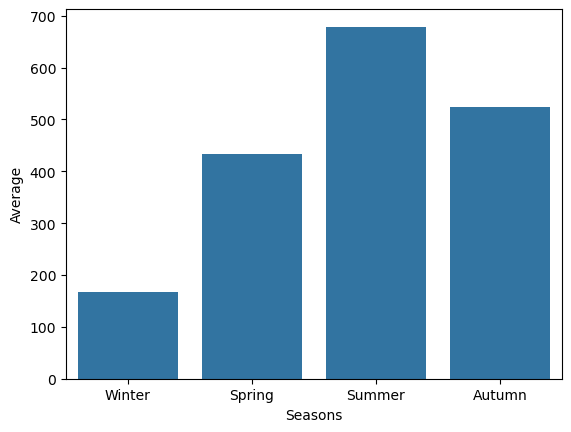

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

data_average_morn = pd.DataFrame(list(average_morn.items()), columns = ['Seasons', 'Average'])

sns.barplot(x = 'Seasons', y = 'Average', data = data_average_morn)
plt.xlabel("Seasons")
plt.ylabel("Average")
plt.show()

In [9]:
average_noon = average_time(12, 18)

Season : Winter, Average: 295.4851851851852
Season : Spring, Average: 986.1757246376811
Season : Summer, Average: 1061.8369565217392
Season : Autumn, Average: 1039.7857142857142


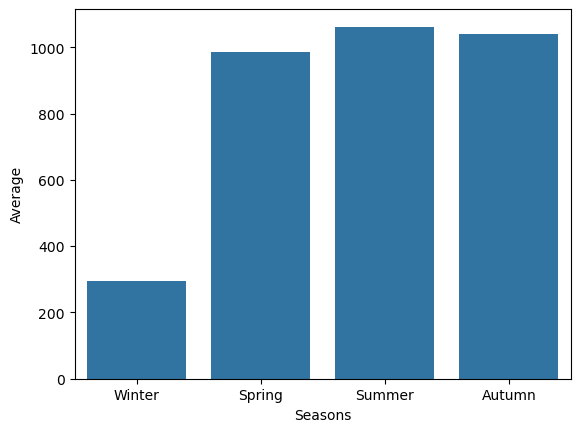

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

data_average_noon = pd.DataFrame(list(average_noon.items()), columns = ['Seasons', 'Average'])

sns.barplot(x = 'Seasons', y = 'Average', data = data_average_noon)
plt.xlabel("Seasons")
plt.ylabel("Average")
plt.show()

In [11]:
average_evening = average_time(18,25)

Season : Winter, Average: 270.77222222222224
Season : Spring, Average: 1066.1467391304348
Season : Summer, Average: 1717.0253623188405
Season : Autumn, Average: 1191.7619047619048


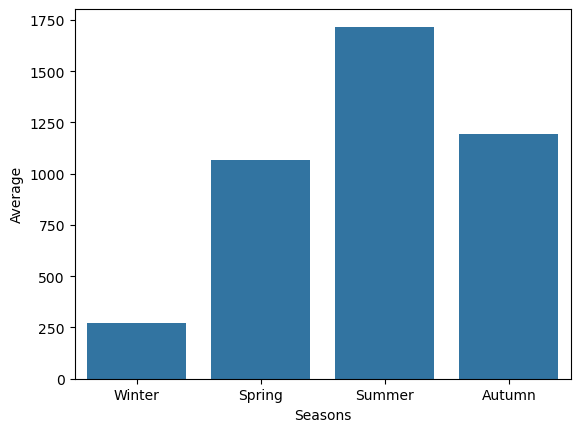

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

data_average_evening = pd.DataFrame(list(average_evening.items()), columns = ['Seasons', 'Average'])

sns.barplot(x = 'Seasons', y = 'Average', data = data_average_evening)
plt.xlabel("Seasons")
plt.ylabel("Average")
plt.show()

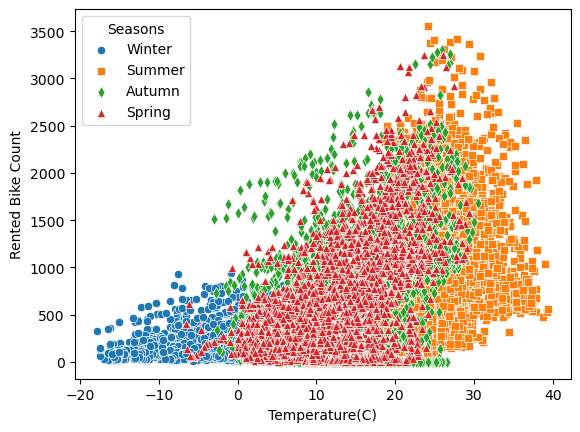

In [13]:
sns.scatterplot(x='Temperature(C)', y='Rented Bike Count', 
                data=seoul[seoul['Seasons'] == 'Winter'], 
                marker='o', label='Winter') 

sns.scatterplot(x='Temperature(C)', y='Rented Bike Count', 
                data=seoul[seoul['Seasons'] == 'Summer'], 
                marker='s', label='Summer')
sns.scatterplot(x='Temperature(C)', y='Rented Bike Count', 
                data=seoul[seoul['Seasons'] == 'Autumn'], 
                marker='d', label='Autumn')
sns.scatterplot(x='Temperature(C)', y='Rented Bike Count', 
                data=seoul[seoul['Seasons'] == 'Spring'], 
                marker='^', label='Spring')
plt.legend(title='Seasons')
plt.show()

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False)

encoded_categorical = encoder.fit_transform(seoul[['Seasons','Holiday','Functioning Day']])

encoded_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(
    ['Seasons','Holiday','Functioning Day']))
df_encoded = pd.concat([seoul.drop(['Seasons','Holiday','Functioning Day','Date'], axis=1), encoded_df], axis=1)
df_encoded

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


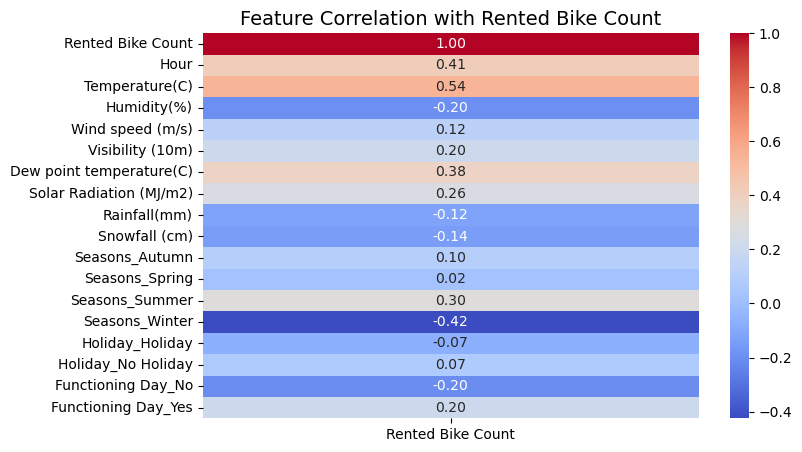

In [15]:
correlation = df_encoded.corr(numeric_only = True)
plt.figure(figsize=(8, 5))  # Set figure size

# Create a heatmap
sns.heatmap(correlation[['Rented Bike Count']], annot=True, cmap='coolwarm', fmt=".2f")

# Title
plt.title("Feature Correlation with Rented Bike Count", fontsize=14)

plt.show()


In [16]:
df_encoded.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)',
       'Seasons_Autumn', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_Holiday', 'Holiday_No Holiday', 'Functioning Day_No',
       'Functioning Day_Yes'],
      dtype='object')

In [17]:
X, y = df_encoded.iloc[:,1:], df_encoded['Rented Bike Count']

In [18]:
X

,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8756,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8757,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8758,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [19]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

model = LinearRegression()
kf = KFold(n_splits=6, shuffle=True, random_state=42)
cv_results = cross_val_score(model,X,y,cv=kf,scoring='r2')
cv_results

array([0.5404189 , 0.51689336, 0.54782128, 0.57342065, 0.54794092,
       0.56142461])

In [20]:
from sklearn.ensemble import RandomForestRegressor
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
cv_results = cross_val_score(model2,X,y,cv=kf,scoring='r2')
cv_results

array([0.86076073, 0.87090069, 0.88747977, 0.87345423, 0.87744922,
       0.8718448 ])

In [21]:
import numpy as np
best_fold_index = np.argmax(cv_results)
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    if fold == best_fold_index:
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        break
model2.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Text(0, 0.5, 'Predicted Rented Bike Count')

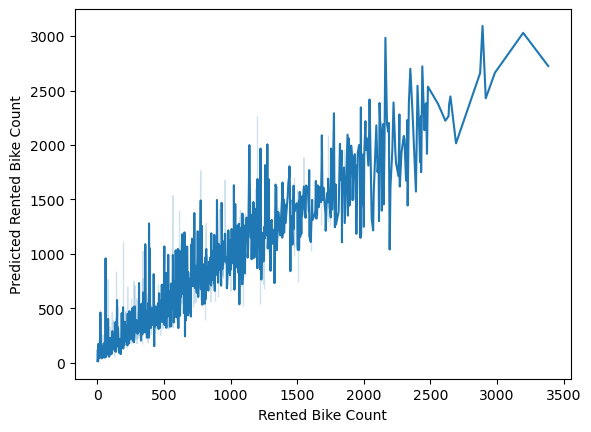

In [22]:
y_pred = model2.predict(X_test)
sns.lineplot(x = y_test, y = y_pred)
plt.ylabel("Predicted Rented Bike Count")

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2-Score: {r2}")

Mean Squared Error: 44824.3453069863
Root Mean Squared Error: 211.71760745622058
R2-Score: 0.8874797665296736
